In [120]:
from spike.spike_analysis.spike_collection import SpikeCollection
import spike.spike_analysis.spike_recording as sr
import spike.spike_analysis.firing_rate_calculations as fr
import spike.spike_analysis.normalization as norm
import spike.spike_analysis.single_cell as single_cell
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import behavior.boris_extraction as boris
import matplotlib.pyplot as plt

In [121]:
import importlib
importlib.reload(sr)

<module 'spike.spike_analysis.spike_recording' from 'c:\\Users\\thoma\\Code\\ResearchCode\\rehouse\\diff_fam_social_memory_ephys\\spike\\spike_analysis\\spike_recording.py'>

In [122]:
pd.set_option('display.max_colwidth', 0)  # 0 means unlimited in newer pandas versions

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Don’t truncate column contents
pd.set_option("display.max_colwidth", None)

# Expand the display to the full width of the screen
pd.set_option("display.width", 0)


In [123]:
json_path = r"C:\Users\thoma\Code\ResearchCode\rehouse\diff_fam_social_memory_ephys\thomas-social-memory\data\spike_collection.json"
sc = SpikeCollection.load_collection(json_path)

In [124]:
# Standardize event dictionaries across all recordings
# Collect all unique event keys
all_event_keys = set()
for recording in sc.recordings:
    if hasattr(recording, 'event_dict'):
        all_event_keys.update(recording.event_dict.keys())

print(f"All unique event types found: {sorted(all_event_keys)}")
print("\nAdding missing event keys to recordings...")

# For each recording, add missing event keys with empty arrays
for recording in sc.recordings:
    if hasattr(recording, 'event_dict'):
        for event_key in all_event_keys:
            if event_key not in recording.event_dict:
                # Add empty numpy array with shape (0, 2) for missing events
                recording.event_dict[event_key] = np.array([]).reshape(0, 2)
                print(f"  {recording.name}: Added empty '{event_key}'")

print("\n✓ Event dictionaries standardized!")
print("\nVerifying all recordings now have the same keys:")
for recording in sc.recordings:
    print(f"{recording.name} keys: {sorted(recording.event_dict.keys())}")

All unique event types found: ['anogenital sniffing', 'chasing', 'facial sniffing', 'fighting', 'mice back in', 'mice taken out', 'sniffing object']

Adding missing event keys to recordings...
  22_rehouse_d0_merged.rec: Added empty 'chasing'
  22_rehouse_d7_merged.rec: Added empty 'chasing'
  31_rehouse_d7_merged.rec: Added empty 'facial sniffing'
  31_rehouse_d7_merged.rec: Added empty 'anogenital sniffing'
  31_rehouse_d7_merged.rec: Added empty 'chasing'
  32_rehouse_d0_merged.rec: Added empty 'facial sniffing'
  32_rehouse_d0_merged.rec: Added empty 'chasing'
  32_rehouse_d0_merged.rec: Added empty 'fighting'
  32_rehouse_d7_merged.rec: Added empty 'chasing'
  32_rehouse_d7_merged.rec: Added empty 'fighting'
  41_rehouse_d0_merged.rec: Added empty 'chasing'
  41_rehouse_d0_merged.rec: Added empty 'fighting'
  41_rehouse_d7_merged.rec: Added empty 'fighting'
  44_rehouse_d0_merged.rec: Added empty 'chasing'
  44_rehouse_d0_merged.rec: Added empty 'fighting'
  44_rehouse_d7_merged.r

In [125]:
sc.recordings[0].event_dict

{'anogenital sniffing': array([[1204874.9 , 1208405.65],
        [1229127.6 , 1231414.3 ],
        [1237304.25, 1237997.15],
        [1243540.65, 1245477.35],
        [1252826.  , 1254489.  ],
        [1331474.1 , 1333067.85],
        [1350114.  , 1354964.55],
        [1363349.1 , 1363695.55],
        [1367298.8 , 1367922.45],
        [1373743.1 , 1376861.3 ],
        [1379840.9 , 1382196.9 ],
        [1383859.95, 1386978.15],
        [1390997.15, 1392105.85],
        [1455301.5 , 1457241.75],
        [1522793.35, 1525149.35],
        [1554460.5 , 1558895.25],
        [1705173.8 , 1705312.4 ],
        [1721734.95, 1724714.55],
        [1774813.75, 1776823.25]]),
 'facial sniffing': array([[1238551.5 , 1238620.8 ],
        [1240630.35, 1241253.95],
        [1247351.8 , 1247421.1 ],
        [1248737.65, 1250677.9 ],
        [1525565.1 , 1526119.45],
        [1530346.35, 1530762.1 ],
        [1576064.15, 1576255.8 ],
        [1705381.7 , 1705866.75],
        [1733029.8 , 1734415.65],
    

In [126]:
sc.analyze(timebin=250)

All set to analyze


c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\scipy\_lib\_util.py:1023: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return fun(*args, **kwargs)


Wilcoxon can't be done on 31_rehouse_d7_merged.rec facial sniffing, because <6 samples
Wilcoxon can't be done on 32_rehouse_d0_merged.rec facial sniffing, because <6 samples


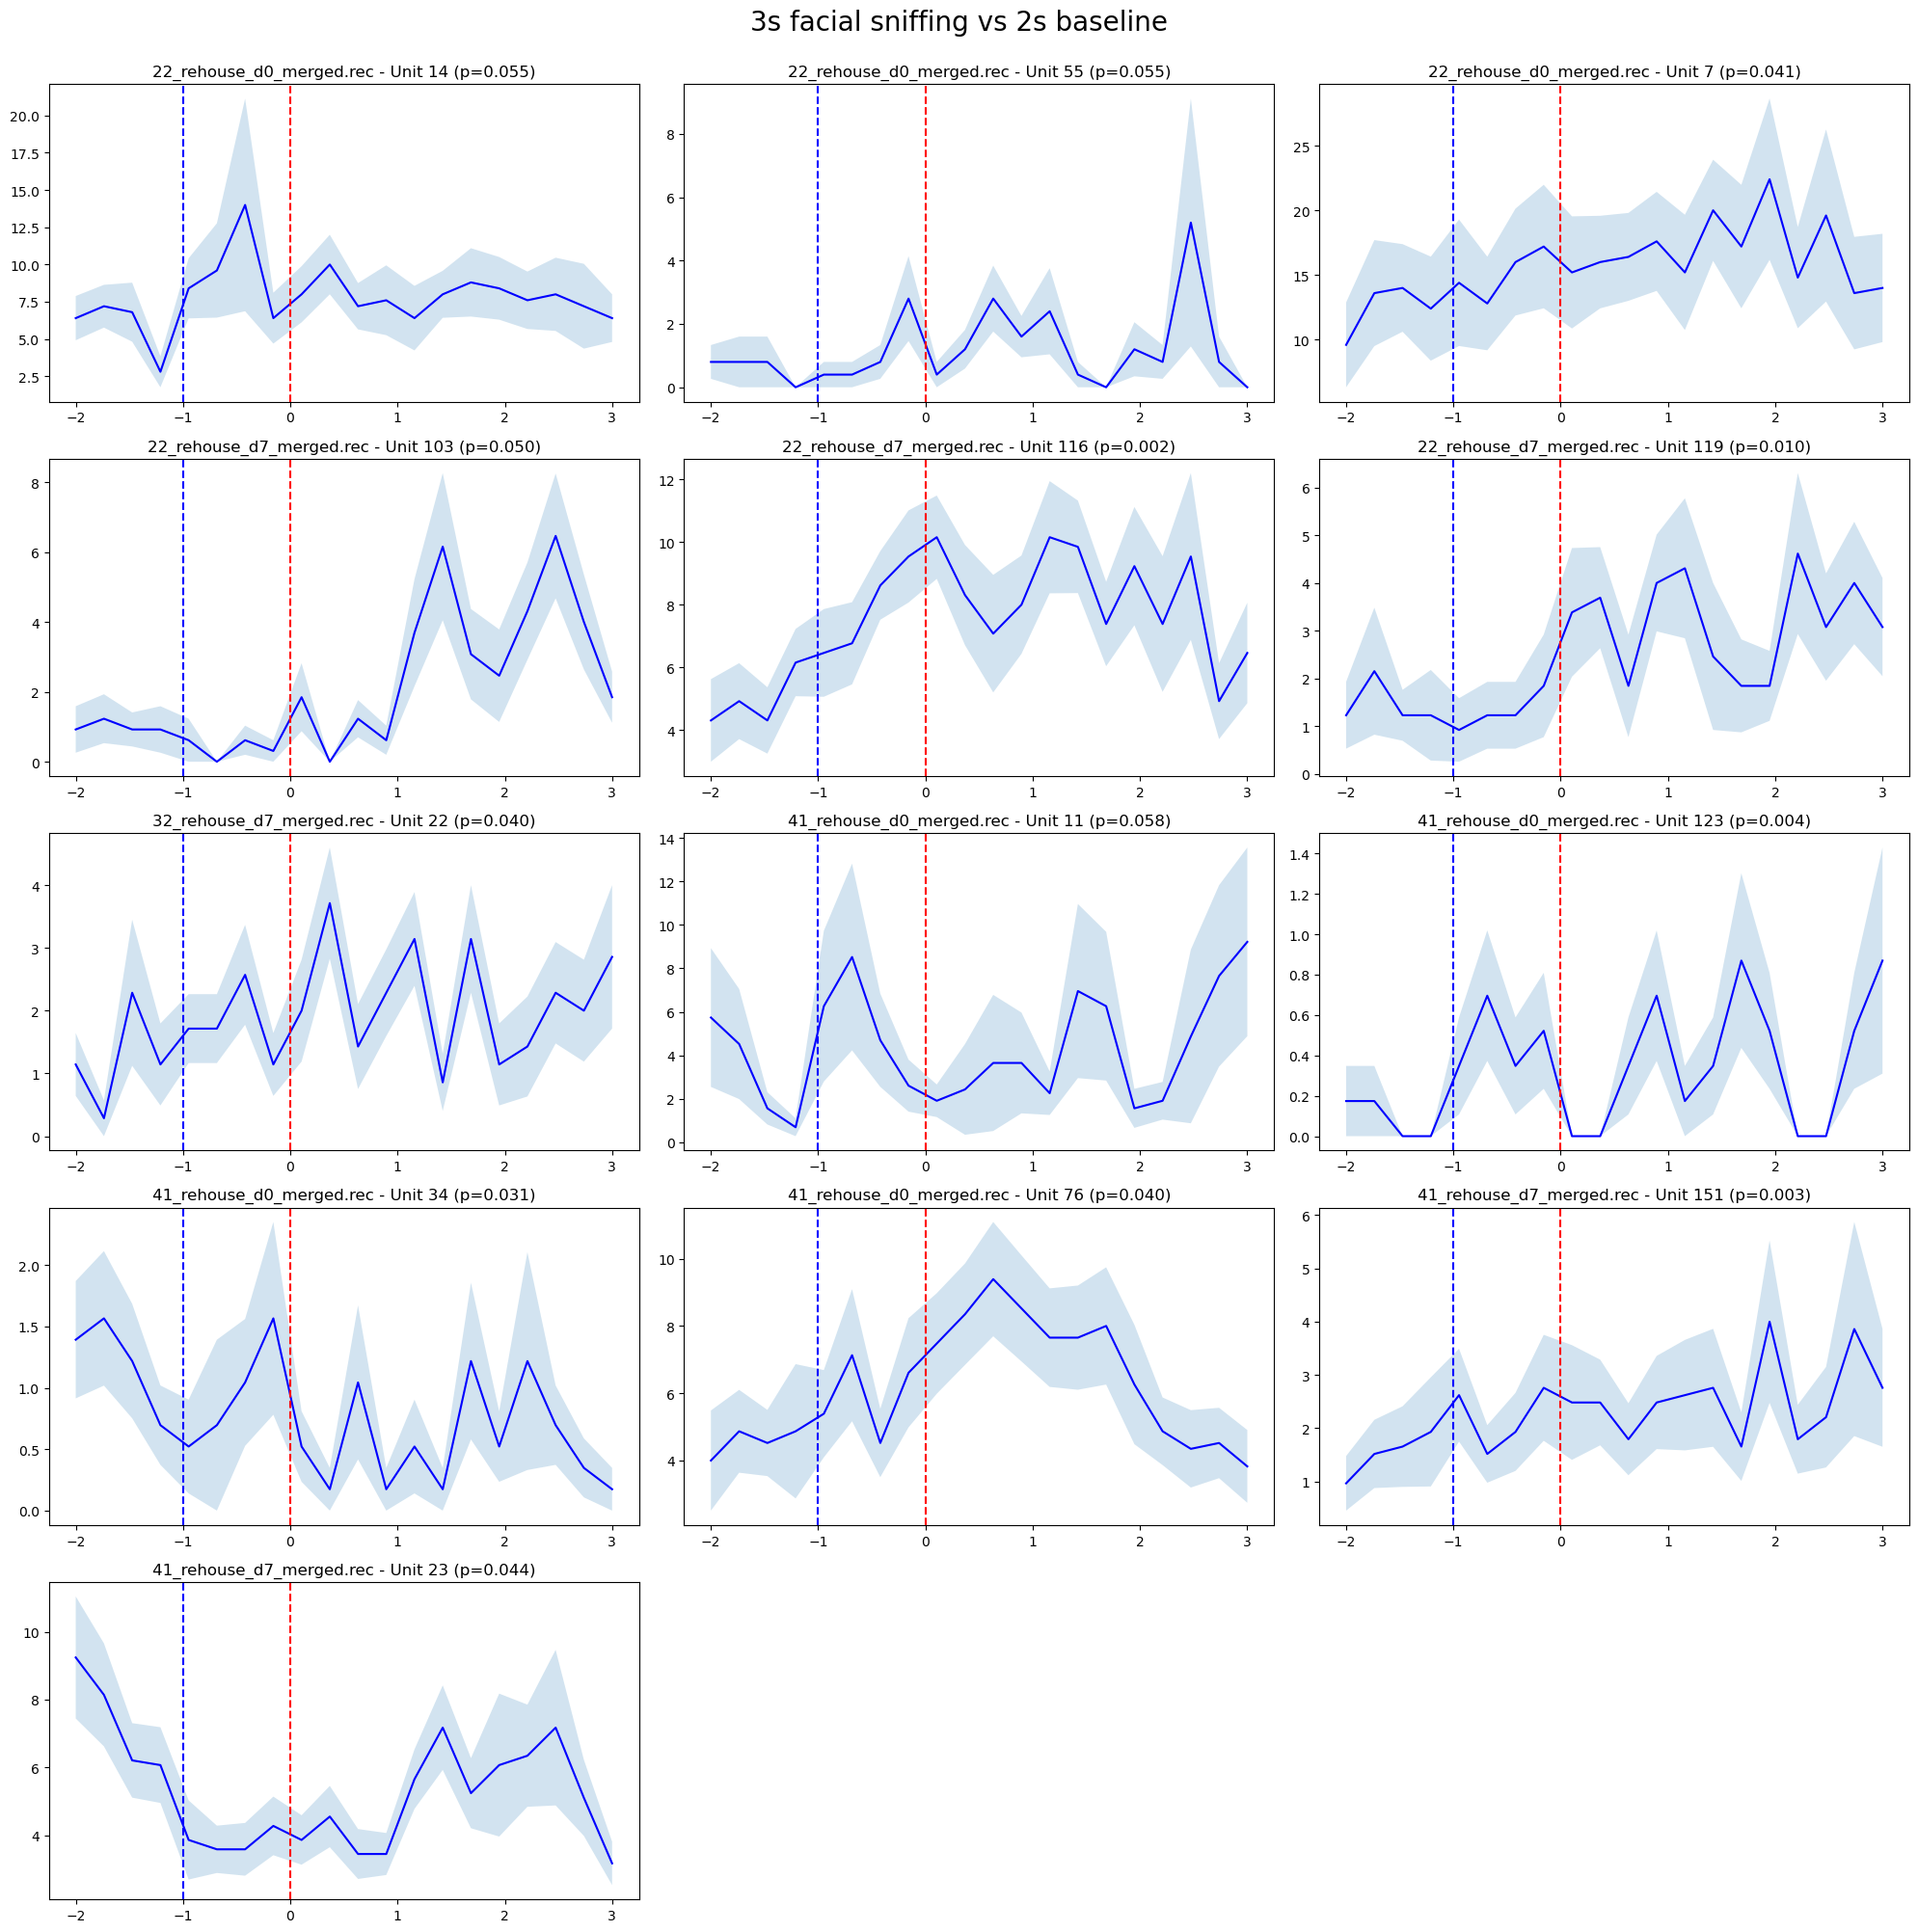

,Event,original unit id,Wilcoxon Stat,p value,Recording,Subject,event1 vs event2
0,3s facial sniffing vs 2s baseline,13,16.0,0.275391,22_rehouse_d0_merged.rec,22,not significant
1,3s facial sniffing vs 2s baseline,14,8.5,0.054688,22_rehouse_d0_merged.rec,22,not significant
2,3s facial sniffing vs 2s baseline,25,NaN,NaN,22_rehouse_d0_merged.rec,22,not significant
3,3s facial sniffing vs 2s baseline,26,19.5,0.742188,22_rehouse_d0_merged.rec,22,not significant
4,3s facial sniffing vs 2s baseline,27,26.5,0.941406,22_rehouse_d0_merged.rec,22,not significant
5,3s facial sniffing vs 2s baseline,3,12.0,0.125000,22_rehouse_d0_merged.rec,22,not significant
6,3s facial sniffing vs 2s baseline,36,21.5,0.574219,22_rehouse_d0_merged.rec,22,not significant
7,3s facial sniffing vs 2s baseline,55,6.0,0.054688,22_rehouse_d0_merged.rec,22,not significant
8,3s facial sniffing vs 2s baseline,56,25.0,0.830078,22_rehouse_d0_merged.rec,22,not significant
9,3s facial sniffing vs 2s baseline,60,13.0,0.160156,22_rehouse_d0_merged.rec,22,not significant


In [127]:
fac_wilcox = single_cell.wilcoxon_collection(spike_collection=sc,
                                event = 'facial sniffing', #name of event used in the event_dict
                                event_length = 3, # in seconds
                                baseline_window=2, # in seconds
                                offset=-1,
                                plot = True)
fac_wilcox         

In [128]:
len(fac_wilcox)
fac_wilcox.head(81)

,Event,original unit id,Wilcoxon Stat,p value,Recording,Subject,event1 vs event2
0,3s facial sniffing vs 2s baseline,13,16.0,0.275391,22_rehouse_d0_merged.rec,22,not significant
1,3s facial sniffing vs 2s baseline,14,8.5,0.054688,22_rehouse_d0_merged.rec,22,not significant
2,3s facial sniffing vs 2s baseline,25,NaN,NaN,22_rehouse_d0_merged.rec,22,not significant
3,3s facial sniffing vs 2s baseline,26,19.5,0.742188,22_rehouse_d0_merged.rec,22,not significant
4,3s facial sniffing vs 2s baseline,27,26.5,0.941406,22_rehouse_d0_merged.rec,22,not significant
5,3s facial sniffing vs 2s baseline,3,12.0,0.125000,22_rehouse_d0_merged.rec,22,not significant
6,3s facial sniffing vs 2s baseline,36,21.5,0.574219,22_rehouse_d0_merged.rec,22,not significant
7,3s facial sniffing vs 2s baseline,55,6.0,0.054688,22_rehouse_d0_merged.rec,22,not significant
8,3s facial sniffing vs 2s baseline,56,25.0,0.830078,22_rehouse_d0_merged.rec,22,not significant
9,3s facial sniffing vs 2s baseline,60,13.0,0.160156,22_rehouse_d0_merged.rec,22,not significant


In [129]:
sig_facial = fac_wilcox[fac_wilcox["event1 vs event2"] == 'increases']
len(fac_wilcox[fac_wilcox["event1 vs event2"] == 'increases'])

10

In [130]:
sig_facial_units = sig_facial['original unit id'].to_list()
print(sig_facial_units)

['7', '103', '116', '119', '22', '123', '34', '76', '151', '23']


Wilcoxon can't be done on 31_rehouse_d7_merged.rec anogenital sniffing, because <6 samples
Wilcoxon can't be done on 32_rehouse_d0_merged.rec anogenital sniffing, because <6 samples


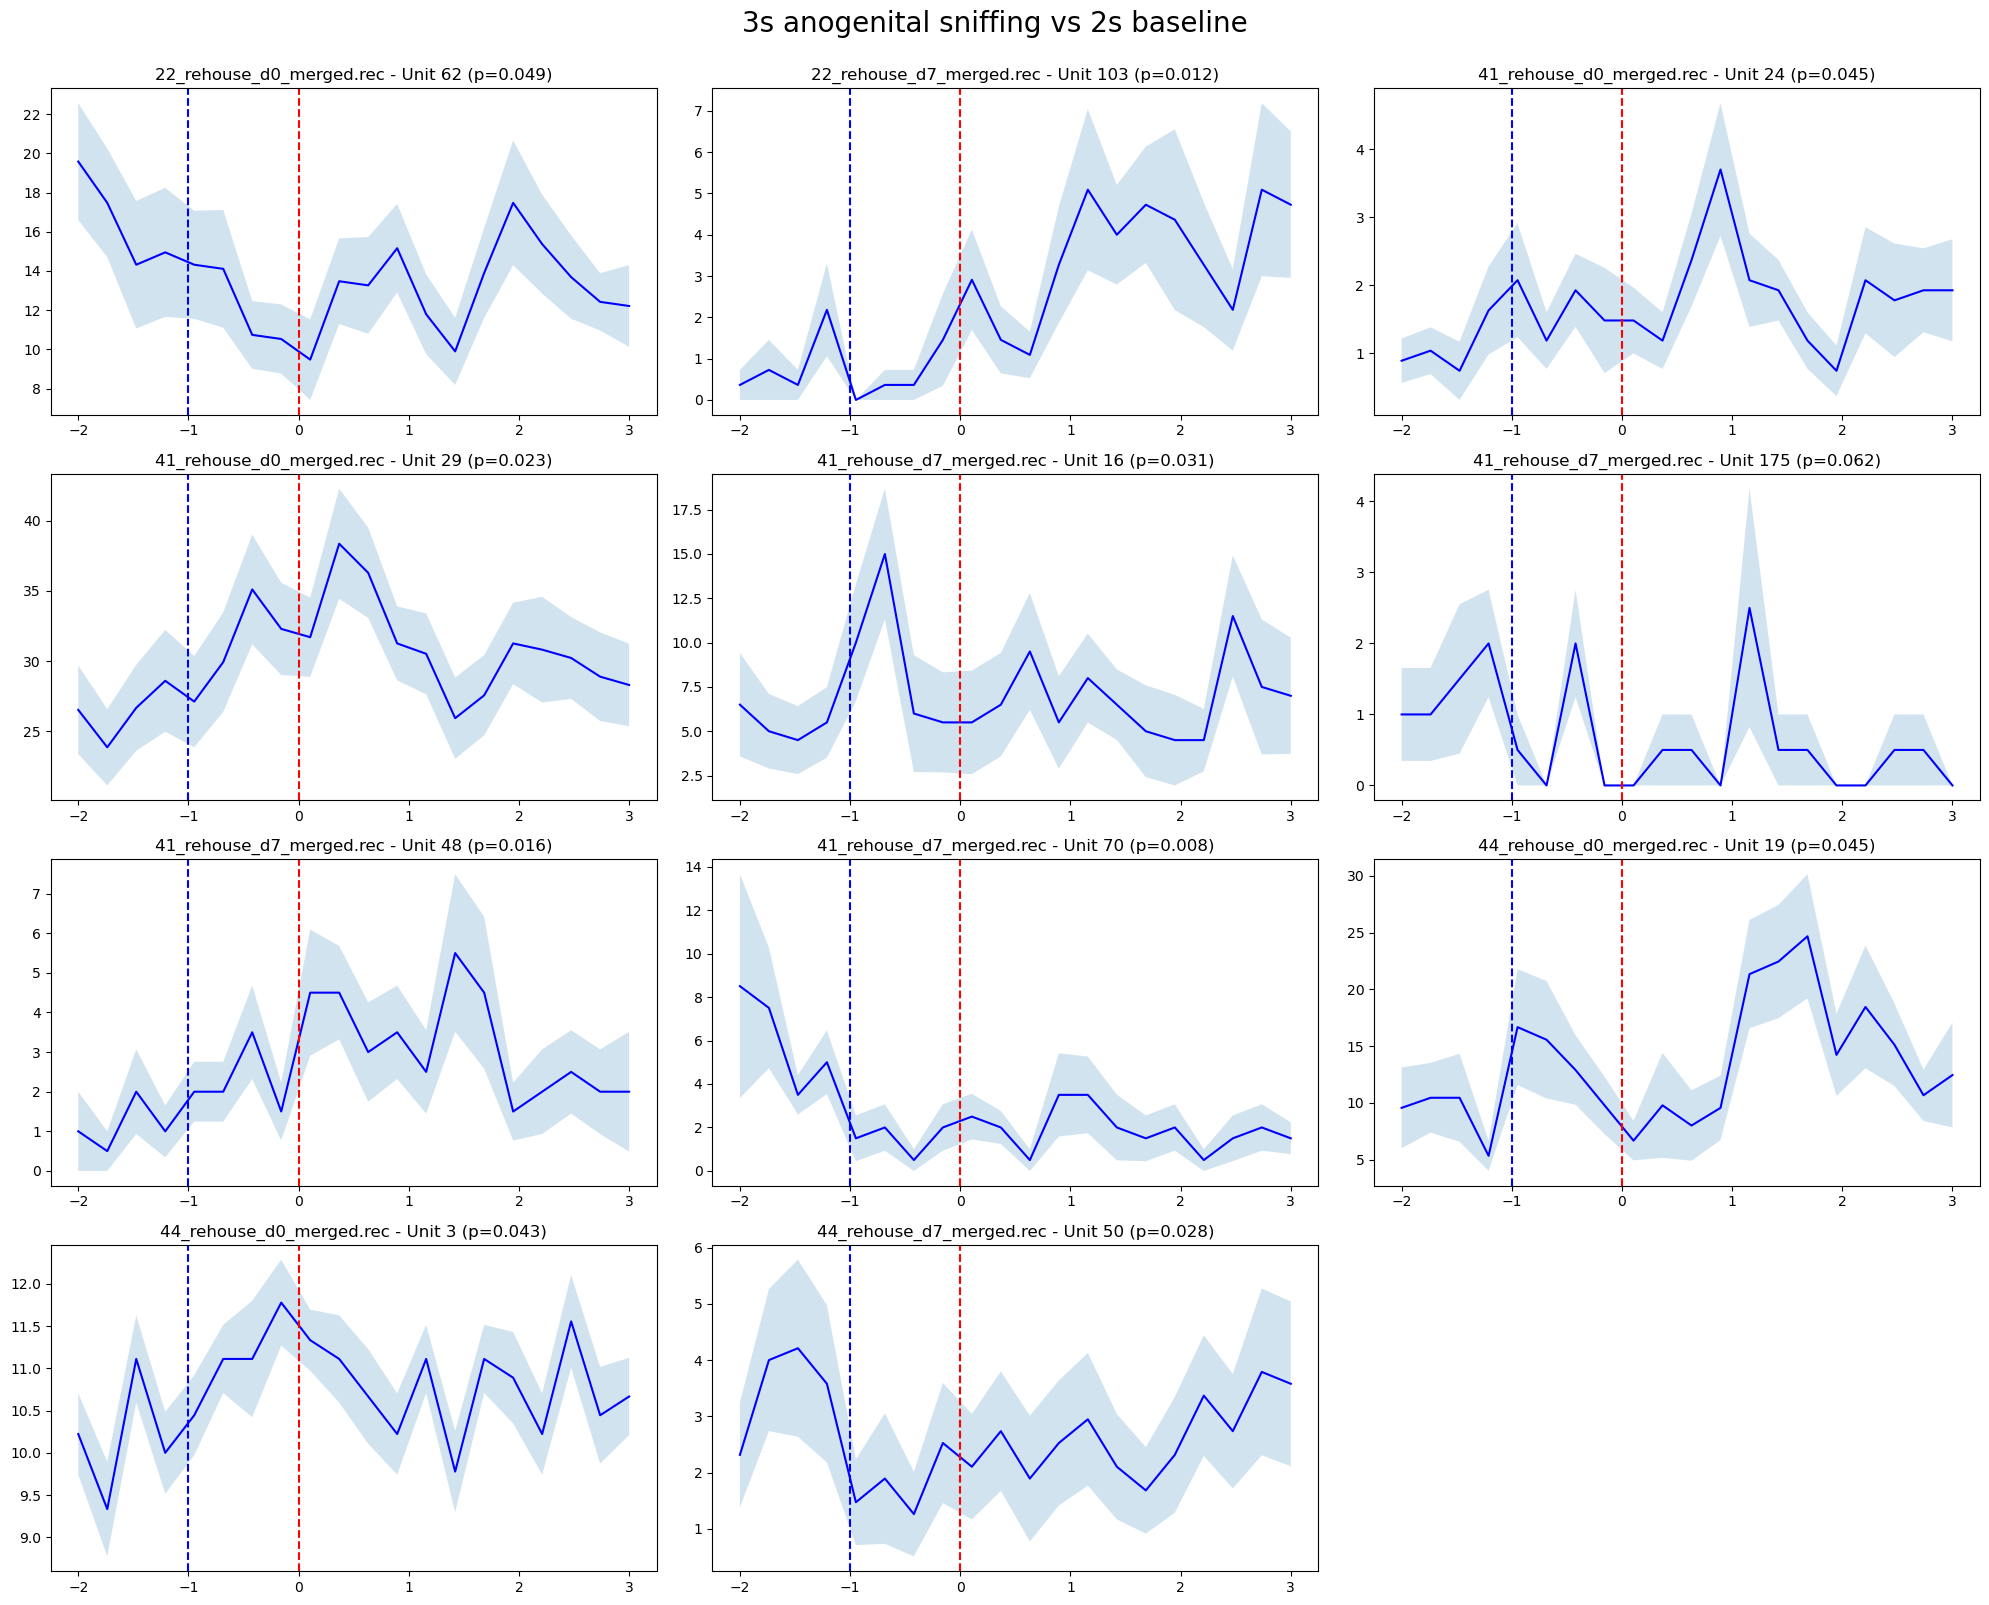

,Event,original unit id,Wilcoxon Stat,p value,Recording,Subject,event1 vs event2
0,3s anogenital sniffing vs 2s baseline,13,56.0,0.331425,22_rehouse_d0_merged.rec,22,not significant
1,3s anogenital sniffing vs 2s baseline,14,75.5,0.432430,22_rehouse_d0_merged.rec,22,not significant
2,3s anogenital sniffing vs 2s baseline,25,6.0,0.375000,22_rehouse_d0_merged.rec,22,not significant
3,3s anogenital sniffing vs 2s baseline,26,51.0,0.075634,22_rehouse_d0_merged.rec,22,not significant
4,3s anogenital sniffing vs 2s baseline,27,62.0,0.491060,22_rehouse_d0_merged.rec,22,not significant
5,3s anogenital sniffing vs 2s baseline,3,78.0,0.493682,22_rehouse_d0_merged.rec,22,not significant
6,3s anogenital sniffing vs 2s baseline,36,54.0,0.169962,22_rehouse_d0_merged.rec,22,not significant
7,3s anogenital sniffing vs 2s baseline,55,71.5,0.342541,22_rehouse_d0_merged.rec,22,not significant
8,3s anogenital sniffing vs 2s baseline,56,79.0,0.518469,22_rehouse_d0_merged.rec,22,not significant
9,3s anogenital sniffing vs 2s baseline,60,50.5,0.127037,22_rehouse_d0_merged.rec,22,not significant


In [131]:
ano_wilcox = single_cell.wilcoxon_collection(spike_collection=sc,
                                event = 'anogenital sniffing', #name of event used in the event_dict
                                event_length = 3, # in seconds
                                baseline_window=2, # in seconds
                                offset=-1,
                                plot = True)
ano_wilcox

In [132]:
# list units with significant changes increases or decreases during object sniffing
sig_ano = ano_wilcox[ano_wilcox["event1 vs event2"] == 'increases']
sig_ano_decreases = ano_wilcox[ano_wilcox["event1 vs event2"] == 'decreases']

sig_ano_units = sig_ano['original unit id'].to_list()
sig_ano_decrease_units = sig_ano_decreases['original unit id'].to_list()

print(sig_ano_units)
print(sig_ano_decrease_units)

print(f"\nAll significant units during anogenital sniffing: {len(sig_ano_units + sig_ano_decrease_units)}")
print(sig_ano_units + sig_ano_decrease_units)

['62', '103', '24', '29', '16', '19', '3', '50']
['48', '70']

All significant units during anogenital sniffing: 10
['62', '103', '24', '29', '16', '19', '3', '50', '48', '70']


In [133]:
# list all increasing or decreasing units during anogenital sniffing
sig_ano_units = sig_ano['original unit id'].to_list()
print(sig_ano_units)

['62', '103', '24', '29', '16', '19', '3', '50']


Wilcoxon can't be done on 31_rehouse_d7_merged.rec sniffing object, because <6 samples


c:\Users\thoma\miniconda3\envs\ephys_env\lib\site-packages\scipy\_lib\_util.py:1023: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return fun(*args, **kwargs)


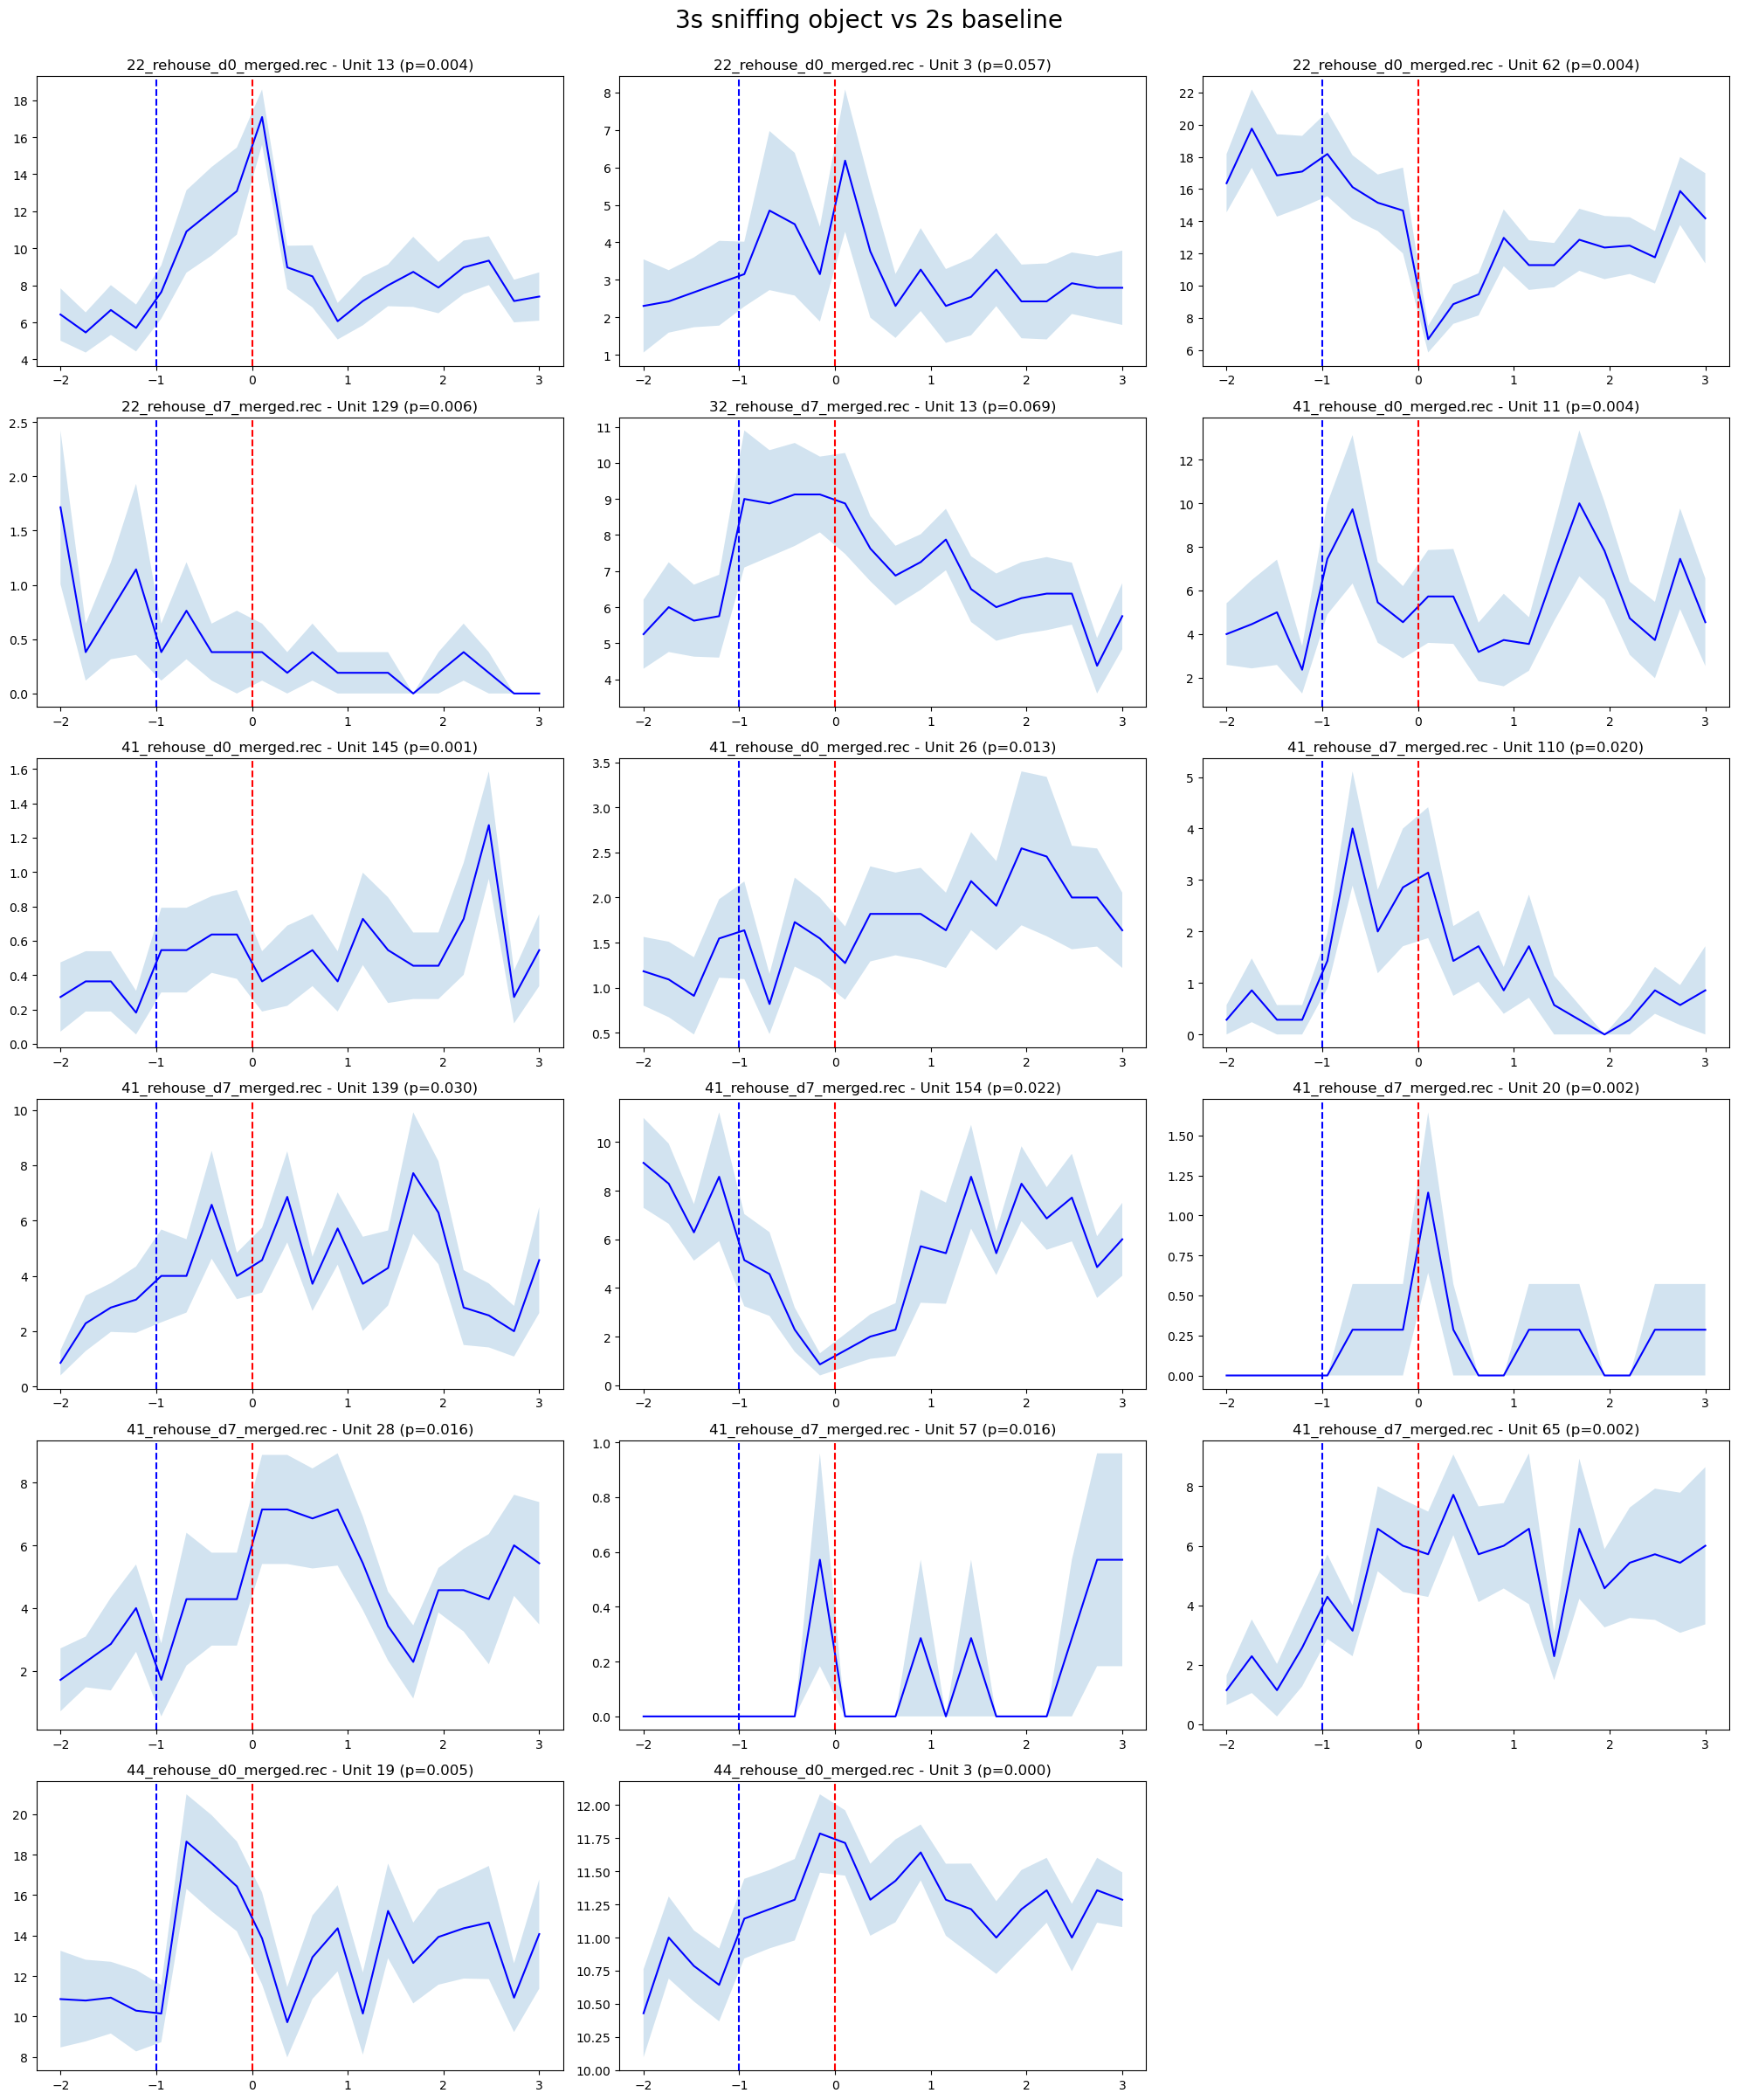

,Event,original unit id,Wilcoxon Stat,p value,Recording,Subject,event1 vs event2
0,3s sniffing object vs 2s baseline,13,117.5,0.003580,22_rehouse_d0_merged.rec,22,increases
1,3s sniffing object vs 2s baseline,14,201.0,0.238670,22_rehouse_d0_merged.rec,22,not significant
2,3s sniffing object vs 2s baseline,25,91.0,0.596570,22_rehouse_d0_merged.rec,22,not significant
3,3s sniffing object vs 2s baseline,26,224.0,0.453537,22_rehouse_d0_merged.rec,22,not significant
4,3s sniffing object vs 2s baseline,27,185.0,0.481850,22_rehouse_d0_merged.rec,22,not significant
5,3s sniffing object vs 2s baseline,3,151.0,0.057200,22_rehouse_d0_merged.rec,22,not significant
6,3s sniffing object vs 2s baseline,36,188.0,0.098222,22_rehouse_d0_merged.rec,22,not significant
7,3s sniffing object vs 2s baseline,55,144.0,0.177850,22_rehouse_d0_merged.rec,22,not significant
8,3s sniffing object vs 2s baseline,56,206.5,0.281468,22_rehouse_d0_merged.rec,22,not significant
9,3s sniffing object vs 2s baseline,60,188.0,0.098102,22_rehouse_d0_merged.rec,22,not significant


In [134]:
exp1_wilcox = single_cell.wilcoxon_collection(spike_collection=sc,
                                event = 'sniffing object', #name of event used in the event_dict
                                event_length = 3, # in seconds
                                baseline_window=2, # in seconds
                                offset=-1,
                                plot = True)
exp1_wilcox         

#### 15 significant units during sniffing object

In [135]:
# count number of increases or decreases in event1 vs event2
len(exp1_wilcox[exp1_wilcox["event1 vs event2"] == 'increases']) + len(exp1_wilcox[exp1_wilcox["event1 vs event2"] == 'decreases'])

15

In [136]:
# list units with significant changes increases or decreases during object sniffing
sig_obj = exp1_wilcox[exp1_wilcox["event1 vs event2"] == 'increases']
sig_obj_decreases = exp1_wilcox[exp1_wilcox["event1 vs event2"] == 'decreases']

sig_obj_units = sig_obj['original unit id'].to_list()
sig_obj_decrease_units = sig_obj_decreases['original unit id'].to_list()

print(sig_obj_units)
print(sig_obj_decrease_units)

['13', '62', '129', '11', '145', '26', '110', '139', '154', '28', '65', '19', '3']
['20', '57']
